In [1]:
# This notebook is to run electron phonon coupling with singular value decomposition (SVD), 
# which can provide different perspective for designing high mobility of OSCs
# Last updated Jun 3rd 2026
import numpy as np
import pandas as pd
import phonopy
import matplotlib.pyplot as plt
import ase.io
from ase import Atoms

In [2]:
print("This notebook is to calculate variance of transfer integral and perform SVD projection\n"
      "Code Explanation:\n"
      "(1) Dimer is formed by 2 monomers\n"
      "(2) Del-J matrix provides the change of transfer integral per unit atomic displacement ...\n"
      "(3) X matrix is the displacement; Q matrix is thermal contribution (coth)\n"
      "--- The user will have to fill up the input parameter below ---")

# ------------------ Input parameter --------------------- #
temp = 300 # TEMPERATURE: Kelvin
mesh = [8,8,8] # phonopy mesh grid
dimer_label = 'c' # label for dimer: {A:(1,2)} {B:(1,3)} {C:(1,4)} {D:(2,3)} {E:(2,4)} {F:(3,4)}
monomer1 = 1 # label for monomer 1
monomer2 = 4 # label for monomer 2
molecule = 'BTBT' # Will be used on naming for the plots
crystal = 'CONTCAR' # The unitcell file path for phonopy simulation
xyz = 'dimer_C.xyz' # dimer xyz file path
n_atoms_xyz = 48 # The number of atoms in dimer file (first line in .xyz file)
dof = n_atoms_xyz * 3 # Degrees of freedom in dimer
xtb = 'n' # Transfer integral simulation is done by xtb or not (y/n)
# Note for the phase exp(-iqR):
# Monomer 1 must in the unitcell, depends on the unitcell. It can be 1 molecule or 2 molecules in the unitcell,
# Different dimer can also have different phase

print("------------------------------------------\n"
       "Input parameters:\n"
       f"Temperature (Kelvin): {temp}\n"
       f"Mesh points for phonopy: {mesh}\n"
       f"Dimer: {dimer_label}; monomer1: {monomer1}; monomer2: {monomer2}\n"
       f"Material: {molecule}\n"
       f"Crystal structure file: {crystal}\n"
       f"Dimer .xyz file: {xyz}\n"
       f"Number of atoms in dimer: {n_atoms_xyz}\n"
       f"Degrees of freedom: {dof}\n"
       "------------------------------------------")
# ------------------ End of Input parameter --------------------- #

This notebook is to calculate variance of transfer integral and perform SVD projection
Code Explanation:
(1) Dimer is formed by 2 monomers
(2) Del-J matrix provides the change of transfer integral per unit atomic displacement ...
(3) X matrix is the displacement; Q matrix is thermal contribution (coth)
--- The user will have to fill up the input parameter below ---
------------------------------------------
Input parameters:
Temperature (Kelvin): 300
Mesh points for phonopy: [8, 8, 8]
Dimer: c; monomer1: 1; monomer2: 4
Material: BTBT
Crystal structure file: CONTCAR
Dimer .xyz file: dimer_C.xyz
Number of atoms in dimer: 48
Degrees of freedom: 144
------------------------------------------


In [3]:
### Define units for each variable ###
mass_au_to_kg = 1.6605e-27 # convert mass from a.u. into kg -> MASS: 1.6605e-27 kg
boltzmann_ev = 8.617e-5 # Boltzmann constant: 8.617e-5 eV/K
boltzmann_J = 1.381e-23 # Boltzmann constant in 1.381e-23 J⋅K−1
planck_J = 6.626e-34 # Planck constant in 6.626e-34 J⋅s
planck_ev = 4.136e-15 # planck constant in 4.1357e−15 eV⋅s;
reduced_planck_J = 1.055e-34 # Reduced constant in J⋅s
thz_to_wnumber = 33.356 # FREQUENCY: 1 THz = 33.356 cm^-1. In phononpy is THz.

In [4]:
def get_deri_Jmatrix(j_list, delta=0.01, tol=1e-12):
    """ Calculate derivative of transfer integral J and return as electron-phonon coupling matrix 
    Args:
        j_list (list): list of transfer integrals for each dimer 
        delta (float): size of displacement (Defaults to 0.01 Angstrom)
        tol (float): If matrix is 0, replace with tol (small value)
    Returns:
        matrix: matrix containing gradient of J_ij
    """
    num_atoms = len(j_list) // 6 # 6 because each atom have 6 displaced treatment, 3 directions (x,y,z) and 2 sign (+ & -)
    # array with j- (negative displacement)
    j_n = np.empty([num_atoms, 3]) 
    j_n[:, 0] = j_list[0::6] # atom x -
    j_n[:, 1] = j_list[2::6] # atom y -
    j_n[:, 2] = j_list[4::6] # atom z -
    # array with j+ (positive displacement)
    j_p = np.empty([num_atoms, 3])
    j_p[:, 0] = j_list[1::6] # atom x +
    j_p[:, 1] = j_list[3::6] # atom y +
    j_p[:, 2] = j_list[5::6] # atom z +

    matrix = (np.abs(j_p) - np.abs(j_n)) / (2 * delta) # The sign in J depends on an arbitrary sign of the basis orbitalt
    mask = np.abs(matrix) < tol # Replace zeros or near-zero values
    matrix[mask] = tol

    return matrix

In [5]:
def ucell_info(crystal, monomer1, monomer2):
    """ Obtain some crystal structure (unitcell) info, would ask the user to provide translation vectors
    Args:
        crystal: crystal structure file
        monomer1 (int): label for monomer 1
        monomer2 (int): label for monomer 2
    Return:
        atoms_ucell: ASE atoms for the unitcell
        atomic_mass: Atomic mass for each atom in unitcell
        n_atoms_ucell: Number of atoms in unitcell
        n_modes (int) : Total number of phonon modes
        t_vecs (list): Translation vectors
        translation_dimer (y/n): Decide whether this dimer is formed by 2 translation molecules or not
    """
    atoms_ucell = ase.io.read(crystal) # Real the unitcell
    n_atoms_ucell = len(atoms_ucell) # number of atoms
    n_modes = 3 * n_atoms_ucell # Number of modes (3N)
    atomic_mass = atoms_ucell.get_masses() # Atomic mass for each atom in unitcell
    com = np.load('../center_of_mass.npz')['arr_0'] # center of mass
    cell = atoms_ucell.get_cell() # cell vectors
    distance = com[monomer2-1] - com[monomer1-1] # distance between center of mass for 2 monomers (distance = ax + by + cz)
    frac = np.linalg.solve(cell.T, distance) # obtain the coefficient 
    dist_vectors = np.abs(np.round(frac, 4)) # this is distance vectors based on the fraction of cell vectors
    print(f"--- Lattice translational vectors: {dist_vectors}\n"
          "If the index smaller than 1, it is still in the unitcell. It should be 0 0 0 (no translation)\n"
          "Please define translation vectors by yourself!!! ---")
    vecs_input = input("Enter numbers separated by space: ")
    t_vecs = list(map(int, vecs_input.split()))
    print("--- If the translation vectors is an positive INTEGER at any direction, select y!!! ---")
    translation_dimer = input("This dimer is formed by tranlsation molecules (y or n)").strip().lower()

    return atoms_ucell, atomic_mass, n_atoms_ucell, n_modes, t_vecs, translation_dimer

In [6]:
def phonon(mesh):
    """ Call phonopy to solve hessian matrix and obtain frequencies and eigenvectors
    Return:
        eigenvecs (array): eigenvectors
        freqs (array): Frequency array in shape of (q, I)
        freqs_flatten (array): Frequency array in shape of Iq (mode index at each qpts) 
        n_qpts (int): Number of qpts
        qpts (array): qpts coordinates 
    """
    print("--- Solving Hessian Matrix (second order derivative of potential energy) by phonopy ---")
    phonon = phonopy.load('phonopy_disp.yaml')
    phonon.run_mesh(mesh=mesh, with_eigenvectors=True)
    mesh_data = phonon.get_mesh_dict() # Solve the hessian matrix
    eigenvecs = mesh_data['eigenvectors']
    freqs = mesh_data['frequencies'] # Shape is (nqpts, natoms*3)
    qpts = mesh_data['qpoints'] 
    print("--- Check whether there is any negative frequencies and remove them ---")
    negative_mask = (freqs < 0).any(axis=1)  # Remove q-points with negative frequency
    valid_mask = ~negative_mask
    n_removed = negative_mask.sum()
    print(f'--- Removing {n_removed} q-points containing imaginary modes ---')
    freqs = freqs[valid_mask]
    eigenvecs = eigenvecs[valid_mask]
    qpts = qpts[valid_mask]
    n_qpts = len(qpts)
    freqs_flatten = freqs.T.flatten()
    print(f'Filtered frequency shape: {freqs.shape}')
    print(f'Number of remaining q-points = {n_qpts}')
    print(f'Eigenvectors shape (qpts, dof, mode) = {eigenvecs.shape}')
    print('--- Finishing Solving Hessian Matrix ---')
    return eigenvecs, freqs, freqs_flatten, n_qpts, qpts

In [7]:
def mapping_atoms(dimer_label, n_atoms_xyz, translation_dimer, xyz):
    """ Map the dimers by reading mapping file, the atomic order need to follow crystal file
    Args: 
        dimer_label (str): a, b, c ...
        n_atoms_xyz (int): number of atoms in dimer
        translation_dimer (y/n): Need special mapping if dimer is translation molecules
        xyz: The dimer structure file path
    Return:
        dimer_map file: The .xyz file after mapping, the atomic index is in order of the atomic index in crystal file
        inverse_mapping: The mapping for crystal to dimer (c1 -> d#, c2 -> d# ...), this will be used to identify an atom is in dimer 1 or 2. This is to identify translation 
        for phase factor
    """
    mapping = np.load(f"../mapping/map_{dimer_label.upper()}.npz")["mapping"] # Dimer to crystal (d1 -> c#, d2 -> c# ...)
    print(f'--- Atomic index mapping (dimer # : crystal #): Ex: d1 -> n; d2 -> m ...\n'
          f'{mapping} ---')
    atoms_xyz = ase.io.read(xyz)
    half_n_atoms_xyz = int(n_atoms_xyz / 2) # the number of atoms for the monomer (half dimer)
    index_for_input = mapping[0:half_n_atoms_xyz].copy()
    index_for_input.sort() # That's the input index for user if translation_dimer
    print(f"----- The INDEX you have to enter if translation dimer: {index_for_input} -----")

    if translation_dimer == 'y': # 2 scenario. If 2 mols in unitcell. Only 1 will be matched. Or 1 mol in unitcell and need to write explicilty
        inverse_mapping1 = list(np.argsort(mapping[0:half_n_atoms_xyz])) # Crystal to dimer (c1 -> d#, c2 -> d# ...)
        inverse_mapping2 = list(np.argsort(mapping[half_n_atoms_xyz:])) # Crystal to dimer (c1 -> d#, c2 -> d# ...)
        inverse_mapping2 = [mp + half_n_atoms_xyz for mp in inverse_mapping2] # Make the index match 2nd monomer by adding the number of atoms im 1 monomer
        inverse_mapping = inverse_mapping1 + inverse_mapping2
        atoms_new_map1 = [None] * (n_atoms_xyz)
        atoms_new_map2 = [None] * (n_atoms_xyz)
        for i in range(0, half_n_atoms_xyz): # i is the index from xyz file
            i_map = mapping[i] # i_map would be the index match the unitcell (i : i_map)
            atoms_new_map1[i_map] = atoms_xyz[i]
        for i in range(half_n_atoms_xyz, n_atoms_xyz): # i is the index from xyz file
            i_map = mapping[i] # i_map would be the index match the unitcell (i : i_map)
            atoms_new_map2[i_map] = atoms_xyz[i]
        atoms_new_map1 = [atom for atom in atoms_new_map1 if atom is not None] # Atoms are in order of unitcell 
        atoms_new_map2 = [atom for atom in atoms_new_map2 if atom is not None] # Atoms are in order of unitcell 
        atoms_map_xyz1 = Atoms(atoms_new_map1)
        atoms_map_xyz2 = Atoms(atoms_new_map2)
        atoms_map_combined = atoms_map_xyz1 + atoms_map_xyz2 # Order: (monomer1, monomer2). Each monomer is in order of unitcell
        ase.io.write(f'dimer_{dimer_label.upper()}_map.xyz', atoms_map_combined, format='xyz')
    else:
        inverse_mapping = np.argsort(mapping) # Crystal to dimer (c1 -> d#, c2 -> d# ...)
        atoms_new_map = [None] * (n_atoms_xyz)
        for i in range(n_atoms_xyz): # i is the index from xyz file
            i_map = mapping[i] # i_map would be the index match the unitcell (i : i_map)
            atoms_new_map[i_map] = atoms_xyz[i]
        atoms_map_xyz = Atoms(atoms_new_map)
        ase.io.write(f'dimer_{dimer_label.upper()}_map.xyz', atoms_map_xyz, format='xyz')

    print('--- Finishing Mapping and Writing dimer_map.xyz file to the folder ---')
    return inverse_mapping

In [8]:
def make_dJ_matrix(dimer_label, molecule, n_atoms_xyz, translation_dimer, xtb):
    """ Create delta J matrix by calling get_deri_J_matrix();
        Map dJ to follow the atomic order in unitcell
    Args:
        dimer_label (str): a, b, c ...
        molecule (str): This is for the naming of delJ.txt file
        n_atoms_xyz: Number of atoms in dimer
        translation_dimer (y/n): If y, this needs special treatment of mapping
        xtb (y/n): If y, read the transfer integral from xtb. If n, read the data from catnip
    Return:
        delJ_matrix: The matrix of numerical derivative of transfer integral J. Shape is (dof, dof)
        delJ_{molecule}_{dimer_label}.txt: The txt file that saves the delta J for each atom at 3 directions
    """
    print('--- Generate delta J matrix ---')
    if xtb == 'n':
        jlist_data = np.loadtxt(f"../disp_j/{dimer_label.upper()}.txt", comments="#", dtype=str)
    else:
        jlist_data = np.loadtxt(f"../disp_j/{dimer_label.upper()}_xtb.txt", comments="#", dtype=str)
    jlist = jlist_data[:,1].astype(float) # n_atoms_xyz * 6 (6 comes from 3 directions and + - 2 ways)
    delJ = get_deri_Jmatrix(jlist) # This will be delta J data 
    print('--- Obtain delta J matrix, now start to map dJ ---')
    mapping = np.load(f"../mapping/map_{dimer_label.upper()}.npz")["mapping"] # Dimer to crystal (d1 -> c#, d2 -> c# ...)
    if translation_dimer == 'y': # 2 scenario. If 2 mols in unitcell. Only 1 will be matched. Or 1 mol in unitcell and need to write explicilty
        delJ_map_li1 = [None] * n_atoms_xyz
        delJ_map_li2 = [None] * n_atoms_xyz
        half_n_atoms_xyz = int(n_atoms_xyz / 2)
        for i in range(0, half_n_atoms_xyz): # i is the index from xyz file
            i_map = mapping[i] # i_map would be the index match the unitcell (i : i_map)
            delJ_map_li1[i_map] = delJ[i]
        for i in range(half_n_atoms_xyz, n_atoms_xyz):
            i_map = mapping[i]
            delJ_map_li2[i_map] = delJ[i]
        delJ_map_li1 = [j for j in delJ_map_li1 if j is not None]
        delJ_map_li2 = [j for j in delJ_map_li2 if j is not None]
        delJ_map_combined = delJ_map_li1 + delJ_map_li2
        delJ_map = np.array(delJ_map_combined)
        delJ_matrix = np.diag(delJ_map.flatten())
    else:
        delJ_map_li = [None] * n_atoms_xyz
        for i in range(n_atoms_xyz): # i is the index from xyz file
            i_map = mapping[i] # i_map would be the index match the unitcell (i : i_map)
            delJ_map_li[i_map] = delJ[i]
        delJ_map = np.array(delJ_map_li)
        delJ_matrix = np.diag(delJ_map.flatten())

    # --- Save delta J --- # 
    np.savetxt(f"delJ_{molecule}_{dimer_label}.txt",
               delJ_map, fmt="%.8e", comments="")
    
    print('--- Finish generating delta J matrix \n'
          f'Delta J matrix shape: {delJ_matrix.shape} ---')

    return delJ_matrix

In [9]:
def make_XQ_matrix(atoms_ucell, atomic_mass, dof, eigenvecs, freqs, inverse_mapping, n_atoms_xyz, n_modes, n_qpts, t_vecs):
    """ Create atomic displacement X matrix and thermal population Q matrix 
    Note: If it's translation dimer, the dimer only match to one molecule in the unitcell (in general there are 2 molecules in unitcell)
    In this case, user have to enter the atomic index in the unitcell to match the situation in dimers (ex: 0 2 4 ...)
    Args:
        select_atoms_input (list): User enter the mapping -> dimer # : crystal #
        atoms_ucell: ASE atoms for the unitcell
        atomic_mass: Atomic mass for each atom in unitcell
        dof (int): Degrees of freedom
        eigenvecs (array): eigenvectors
        freqs (array): Frequency array in shape of (q, I)
        inverse_mapping (list):  The mapping for crystal to dimer (c1 -> d#, c2 -> d# ...), this will be used to identify atom is in dimer 1 or 2
        n_atoms_xyz (int): number of atoms in dimer
        n_modes (int) : Total number of phonon modes
        n_qpts (int): Number of qpts
        t_vecs (list): Translation vectors
    Return:
        X_allq: X matrix 
        Q_allq: Q vectors
    """
    select_atoms_input = input("Enter the index of atoms in the unitcell that will be calculated (Press enter will calculated all atoms (When it's not translation dimer))\n"
                               "If translation dimer, enter the unique unit-cell atom indices corresponding to one monomer (ex: 0 1 2 3 0 1 2 3, enter: 0 1 2 3)").strip()
    if select_atoms_input == "":
        select_atoms = []  # means all atoms
    elif "-" in select_atoms_input: # Ex: 0-3 
        start, end = map(int, select_atoms_input.split("-"))
        base_list = list(range(start, end + 1))
        select_atoms = base_list + base_list  # duplicate for dimer
    else: # Ex: 0 1 2 3
        base_list = list(map(int, select_atoms_input.split()))
        select_atoms = base_list + base_list  # duplicate for dimer
  
    n_Iq = n_modes * n_qpts # Number of modes * numer of q-points
    l_v = np.ones(shape=(1,dof)) # left row 1 vector
    r_v = np.ones(shape=(dof,1)) # right column 1 vector
    X_allq = np.zeros((dof, n_Iq), dtype=np.complex128)
    Q_allq = np.zeros(n_Iq, dtype=np.float32) # it is an array because matrix takes large memory
    freq_list = []
    Iq = 0 # the index for Iq
    
    if len(select_atoms) > 0:
        new_atoms = atoms_ucell[select_atoms] # Reformulate unitcell atoms by user selection atoms
        new_atomic_mass = new_atoms.get_masses()
        for I in range(n_modes): # loop over phonon modes index 
            for q in range(n_qpts): # loop over q-points index
                freq = freqs[q][I]
                freq_list.append(freq)
                Q2 = 1 / np.tanh((planck_J*freq*1e12) / (2*boltzmann_J*temp)) # coth(hbar*omega/2kT)
                Q_allq[Iq] = np.sqrt(Q2) # diagonal matrix for sqrt(coth(...))
                for i, k in enumerate(select_atoms): # k is the index in crystal
                    am = new_atomic_mass[i] * mass_au_to_kg # atomic mass
                    pref = np.sqrt(reduced_planck_J / (4*np.pi*am*freq*1e12)) * 1e10 # from meter to angstrom
                    check_map = inverse_mapping[i] # Check the atom is in dimer 1 or dimer 2 by the value of index
                    if check_map < n_atoms_xyz / 2: # Atoms in 1st dimer (no translation)
                        for ll in (0, 1, 2): # loop over x,y,z directions
                            phase = 1
                            eps = eigenvecs[q, k * 3 + ll, I]
                            uq = eps * pref * phase / np.sqrt(n_qpts)
                            X_allq[i * 3 + ll, Iq] = uq 
                    
                    elif check_map >= n_atoms_xyz / 2: # Atoms in 2nd dimer (from user definition)
                        phase = np.exp(-2j*np.pi * np.dot(qpts[q], t_vecs))
                        for ll in (0, 1, 2): # loop over x,y,z directions
                            eps = eigenvecs[q, k * 3 + ll, I]
                            uq = eps * pref * phase / np.sqrt(n_qpts)
                            X_allq[i * 3 + ll, Iq] = uq 
                Iq += 1
    else:
        n_atoms_ucell = len(atoms_ucell)
        for I in range(n_modes): # loop over phonon modes index 
            for q in range(n_qpts): # loop over q-points index q
                freq = freqs[q][I]
                freq_list.append(freq)
                Q2 = 1 / np.tanh((planck_J*freq*1e12) / (2*boltzmann_J*temp)) # coth(hbar*omega/2kT)
                Q_allq[Iq] = np.sqrt(Q2) # diagonal matrix for sqrt(coth(...))
                for k in range(n_atoms_ucell): # loop over atomic index k
                    am = atomic_mass[k] * mass_au_to_kg # atomic mass
                    pref = np.sqrt(reduced_planck_J / (4*np.pi*am*freq*1e12)) * 1e10 # from meter to angstrom
                    check_map = inverse_mapping[k]
                    if check_map < n_atoms_xyz / 2: # Atoms in 1st monomer (no translation)
                        for ll in (0, 1, 2): # loop over x,y,z directions
                            phase = 1
                            eps = eigenvecs[q, k * 3 + ll, I]
                            uq = eps * pref * phase / np.sqrt(n_qpts)
                            X_allq[k * 3 + ll, Iq] = uq 
                    
                    elif check_map >= n_atoms_xyz / 2: # Atoms in 2nd monomer (from user definition)
                        phase = np.exp(-2j*np.pi * np.dot(qpts[q], t_vecs))
                        for ll in (0, 1, 2): # loop over x,y,z directions
                            eps = eigenvecs[q, k * 3 + ll, I]
                            uq = eps * pref * phase / np.sqrt(n_qpts)
                            X_allq[k * 3 + ll, Iq] = uq 
                Iq += 1

    print(f'X matrix: {X_allq.shape}; Q vectors: {Q_allq.shape}\n'
          'Q should be the matrix but to save the memory -> vectors are efficient')
    return X_allq, Q_allq, freq_list

In [10]:
def run_SVD(dof, delJ_matrix, n_modes, X_allq, Q_allq):
    """ Run numpy svd function to obtain 3 matrix: U, S and V dagger.
    Args: 
        dof (int): Degrees of freedom
        delJ_matrix: The matrix of numerical derivative of transfer integral J. Shape is (dof, dof)
        n_modes (int): Number of phonon modes
        X_allq: X matrix 
        Q_allq: Q vectors
    Return:
        U: U matrix
        S (array): Singular value array
        V_dag: V dagger matrix
        var_svd: SVD variance
        var_svd_list: A list saves variance of each SVD projected phonon mode
    """
    print("--- Run SVD projection ---")
    l_v = np.ones(shape=(1,dof)) # left row 1 vector
    r_v = np.ones(shape=(dof,1)) # right column 1 vector
    XQ = X_allq * Q_allq[None, :]
    svd_input = delJ_matrix @ XQ
    U, S, V_dag = np.linalg.svd(svd_input, full_matrices=False)
    S_mx = np.diag(S) # Diagonal matrix of singular values
    var_svd = (l_v @ U @ S_mx**2 @ U.conj().T @ r_v).real # Use SVD to calculate variance again
     
    print(f'U matrix shape: {U.shape}\n'
          f'Number of singular value: {S.shape}\n'
          f'V dagger matrix shape: {V_dag.shape}')

    var_svd_list = [] # SVD variance per projected mode
    for I in range(0, n_modes): 
        var_svd_single = (l_v @ U[:, I]) * S[I]**2 * (U[:, I].conj().T @ r_v)
        var_svd_list.append(var_svd_single[0].real)

    print("--- Finish SVD projection ---")
    return U, S, V_dag, var_svd, var_svd_list

In [11]:
def analyze_SVD(dimer_label, delJ_matrix, n_modes, n_qpts, Q_allq, U, V_dag):
    """ Obtain U tilde matrix and save the projected mode atomic motions;
        Obtain V dag tilde matrix and dave the population from the orginal phonon modes
    Args:
        dimer_label (str): a, b, c ...
        delJ_matrix: The matrix of numerical derivative of transfer integral J 
        n_modes (int): Number of phonon modes
        n_qpts (int): Number of qpts
        Q_allq: Q vectors
        U: U matrix
        V_dag: V dagger matrix
    Return:
        disp_{dimer_label}_{ip+1}.txt
        V_dag_tilt: population matrix for each phonon at each wavevector q
    """
    U_tilt = np.linalg.inv(delJ_matrix) @ U # Create U tilde matrix: the matrix to describe atomic motion by SVD (you should pick column)
    for ip in range(n_modes): # Loop through number of projected modes
        disp = U_tilt[:,ip].real
        disp_cart = disp.reshape(-1,3)
        np.savetxt(f"disp/disp_{dimer_label}_PM-index_{ip}.txt", disp_cart)

    V_dag_tilt = V_dag / Q_allq[None, :] # Create V_dag tilde matrix: the matrix to describe the SVD projection (you should pick row)
    
    return V_dag_tilt

In [12]:
def calc_variance(dof, delJ_matrix, X_allq, Q_allq, n_modes, n_qpts):
    """ Variance calculations. 
    Args:
        dof (int): Degrees of freedom
        delJ_matrix: The matrix of numerical derivative of transfer integral J 
        X_allq: X matrix 
        Q_allq: Q vectors
        n_modes (int) : Total number of phonon modes
        n_qpts (int): Number of qpts
    Return:
        var_total: Total variance from original phonons
        var_a: Variance from acoustic phonons
        var_o: Variance from optical phonons
        var_plot_mode_list: A list saves variance for each original phonons
        var_plot_wn_list: A list saves variance for each original phonons based on wavenumber
        var_atom_cross: A list saves variance for each atom with crossing term
    """
    print("--- Calculate variance of transfer integral ---")
    l_v = np.ones(shape=(1,dof)) # left row 1 vector
    r_v = np.ones(shape=(dof,1)) # right column 1 vector
    XQ = X_allq * Q_allq[None, :]
    var_total = l_v @ delJ_matrix @ (XQ @ XQ.conj().T).real @ delJ_matrix.T @ r_v # Variance is calculated here
    var_a = l_v @ delJ_matrix @ (XQ[:,0:3*n_qpts] @ XQ[:,0:3*n_qpts].conj().T).real @ delJ_matrix.T @ r_v # Variance from acoustic modes
    var_o = l_v @ delJ_matrix @ (XQ[:,3*n_qpts:] @ XQ[:,3*n_qpts:].conj().T).real @ delJ_matrix.T @ r_v # Variance from optical modes

    dJ_diag = np.diag(delJ_matrix)
    var_matrix = dJ_diag[:, None] * (XQ @ XQ.conj().T).real * dJ_diag[None, :]
    var_atom_cross = np.zeros((int(dof/3), int(dof/3))) # atomic variance
    for k1 in range(int(dof/3)):
        rows_a = slice(3 * k1, 3 * k1 + 3)
        for k2 in range(int(dof/3)):
            rows_b = slice(3 * k2, 3 * k2 + 3)
            var_atom_cross[k1, k2] = np.sum(var_matrix[rows_a, rows_b])

    var_plot_mode_list = [] # variance vs mode index
    var_plot_wn_list = [] # variance vs mode wavenumber
    for I in range(0, n_modes):
        var_plot_mode = 0
        for q in range(n_qpts):
            iq = I * n_qpts + q
            value = l_v @ delJ_matrix @ XQ[:,iq]
            var = value @ value.conj()
            var_plot_mode += var.real
            var_plot_wn_list.append(var.real)
        var_plot_mode_list.append(var_plot_mode)

    return var_total.item(), var_a.item(), var_o.item(), var_plot_mode_list, var_plot_wn_list, var_atom_cross

In [13]:
# ---------- Call the functions here --------------# 
atoms_ucell, atomic_mass, n_atoms_ucell, n_modes, t_vecs, translation_dimer = ucell_info(crystal, monomer1, monomer2)
eigenvecs, freqs, freqs_flatten, n_qpts, qpts = phonon(mesh)
inverse_mapping = mapping_atoms(dimer_label, n_atoms_xyz, translation_dimer, xyz)
delJ_matrix = make_dJ_matrix(dimer_label, molecule, n_atoms_xyz, translation_dimer, xtb)
X_allq, Q_allq, freq_list = make_XQ_matrix(atoms_ucell, atomic_mass, dof, eigenvecs, freqs, inverse_mapping, n_atoms_xyz, n_modes, n_qpts, t_vecs)
U, S, V_dag, var_svd, var_svd_list = run_SVD(dof, delJ_matrix, n_modes, X_allq, Q_allq)
var_total, var_a, var_o, var_plot_mode_list, var_plot_wn_list, var_atom_cross = calc_variance(dof, delJ_matrix, X_allq, Q_allq, n_modes, n_qpts)
V_dag_tilt = analyze_SVD(dimer_label, delJ_matrix, n_modes, n_qpts, Q_allq, U, V_dag) # call the function to deal with U tilde and V tilde

--- Lattice translational vectors: [0. 1. 0.]
If the index smaller than 1, it is still in the unitcell. It should be 0 0 0 (no translation)
Please define translation vectors by yourself!!! ---


Enter numbers separated by space:  0 1 0


--- If the translation vectors is an positive INTEGER at any direction, select y!!! ---


This dimer is formed by tranlsation molecules (y or n) y


--- Solving Hessian Matrix (second order derivative of potential energy) by phonopy ---
--- Check whether there is any negative frequencies and remove them ---
--- Removing 0 q-points containing imaginary modes ---
Filtered frequency shape: (128, 144)
Number of remaining q-points = 128
Eigenvectors shape (qpts, dof, mode) = (128, 144, 144)
--- Finishing Solving Hessian Matrix ---
--- Atomic index mapping (dimer # : crystal #): Ex: d1 -> n; d2 -> m ...
[ 0  4  8 12 18 20 24 28 34 36 40 44  2  6 10 14 16 22 26 30 32 38 42 46
 16 22 26 30 32 38 42 46  0  4  8 12 18 20 24 28 34 36 40 44  2  6 10 14] ---
----- The INDEX you have to enter if translation dimer: [ 0  2  4  6  8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38 40 42 44 46] -----
--- Finishing Mapping and Writing dimer_map.xyz file to the folder ---
--- Generate delta J matrix ---
--- Obtain delta J matrix, now start to map dJ ---
--- Finish generating delta J matrix 
Delta J matrix shape: (144, 144) ---


Enter the index of atoms in the unitcell that will be calculated (Press enter will calculated all atoms (When it's not translation dimer))
If translation dimer, enter the unique unit-cell atom indices corresponding to one monomer (ex: 0 1 2 3 0 1 2 3, enter: 0 1 2 3) 0 2 4 6 8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38 40 42 44 46


X matrix: (144, 18432); Q vectors: (18432,)
Q should be the matrix but to save the memory -> vectors are efficient
--- Run SVD projection ---
U matrix shape: (144, 144)
Number of singular value: (144,)
V dagger matrix shape: (144, 18432)
--- Finish SVD projection ---
--- Calculate variance of transfer integral ---


In [14]:
# ----------- Output parameters -------------- #
print("Output parameters:\n"
      f'1. The first 10 singular values: {S[0:10]}\n'
      f'2. The variance by acoustic modes: {np.round(var_a,6)}\n'
      f'3. The variance by optical modes: {np.round(var_o,6)}\n'
      f'4. Variance for {molecule} {dimer_label}: {np.round(var_total,6)}\n'
      f'5. Dynamic disorder for {molecule} {dimer_label}: {np.round(np.sqrt(var_total),3)} eV')
# ----------- End of Output parameters -------------- #

Output parameters:
1. The first 10 singular values: [0.04697098 0.02983134 0.02379554 0.018434   0.01716342 0.01337379
 0.01259894 0.00991021 0.00934647 0.00878682]
2. The variance by acoustic modes: 0.000566
3. The variance by optical modes: 0.000637
4. Variance for BTBT c: 0.001203
5. Dynamic disorder for BTBT c: 0.035 eV


In [15]:
# ---- We will reorder the projected mode here, which will be descending for the value of variance ---- #
var_svd_array = np.array(var_svd_list)
svd_sorted_indices = np.argsort(var_svd_array)[::-1]  # descending
var_svd_list_order = var_svd_array[svd_sorted_indices]
print(f'The variance from SVD projected modes in the original order (first 10): {var_svd_array[0:10]}')
print(f'The variance from SVD projected modes in descending order (first 10): {var_svd_list_order[0:10]}')
print(f'The first 10 indices (descending order): {svd_sorted_indices[0:10]}')

The variance from SVD projected modes in the original order (first 10): [1.70994827e-05 3.99828054e-04 6.97388522e-05 9.43408138e-05
 1.44806487e-04 1.34143315e-05 1.73997384e-05 1.47601414e-05
 5.14713155e-06 2.42966328e-06]
The variance from SVD projected modes in descending order (first 10): [3.99828054e-04 1.44806487e-04 9.43408138e-05 6.97388522e-05
 6.44252169e-05 5.01332373e-05 4.10124028e-05 4.02626508e-05
 2.47723107e-05 2.27744114e-05]
The first 10 indices (descending order): [ 1  4  3  2 20 37 19 32 11 27]


In [16]:
primary_index = svd_sorted_indices[0:3]
var_p = np.sum(var_svd_array[primary_index]) # Primary mode variance (first 3 modes)
var_b = np.sum(var_svd_array) - var_p # Bath mode variance
print(f'1. Variance from primary modes: {np.round(var_p,6)}\n'
      f'2. Variance from bath modes: {np.round(var_b,6)}\n'
      f'3. Variance from primary + bath modes: {np.round((var_p + var_b),6)}\n'
      f'4. Variance from original modes: {np.round(var_total,6)}\n'
      f'5. Percentage of variance of primary modes to the system modes: {np.round((var_p / var_total),4) * 100}')

1. Variance from primary modes: 0.000639
2. Variance from bath modes: 0.000564
3. Variance from primary + bath modes: 0.001203
4. Variance from original modes: 0.001203
5. Percentage of variance of primary modes to the system modes: 53.13


In [17]:
# Write the parameters into .txt files
# --- Electron phonon coupling --- #
l_v = np.ones(shape=(1,dof))
epc = l_v @ delJ_matrix @ X_allq
epc = np.abs(epc.real)
epc = epc.squeeze()

# --- Save electron phonon coupling --- #
np.savetxt(
    f"epc_{molecule}_{dimer_label}.txt",
    epc,
    fmt="%.8e",
    comments=""
)

# --- Save frequencies in wavenumber unit --- #
np.savetxt(
    f"freq_{molecule}.txt",
    freqs_flatten*thz_to_wnumber,
    fmt="%.8e",
    comments=""
)

# --- Save the variance vs frequencies --- #
np.savetxt(
    f"variance_{molecule}_{dimer_label}.txt",
    var_plot_wn_list,
    fmt="%.8e",
    comments=""
)

# --- Save the svd variance vs mode index --- #
np.savetxt(
    f"variance_svd_{molecule}_{dimer_label}.txt",
    var_svd_list_order,
    fmt="%.8e",
    comments=""
)

# --- Save the variance vs atomic index --- #
np.savetxt(
    f"variance_atomic_{molecule}_{dimer_label}.txt",
    np.diag(var_atom_cross) * 1e4,
    fmt="%.8e",
    comments=""
)

np.savez(
    f"trajectory_inputs_{molecule}_{dimer_label}.npz",
    X=X_allq,
    pop=V_dag_tilt,
    freq=freqs_flatten,
    index=svd_sorted_indices,
)

In [18]:
U_sel = U[:, primary_index]
S_sel = S[primary_index]
var_svd_matrix = (U_sel @ np.diag(S_sel**2) @ U_sel.conj().T).real
var_svd_atom_cross = np.zeros((n_atoms_xyz, n_atoms_xyz))
for k1 in range(n_atoms_xyz):
    rows_a = slice(3 * k1, 3 * k1 + 3)
    for k2 in range(n_atoms_xyz):
        rows_b = slice(3 * k2, 3 * k2 + 3)
        var_svd_atom_cross[k1, k2] = np.sum(var_svd_matrix[rows_a, rows_b])

print(np.sum(var_svd_atom_cross))

# --- Save the variance vs atomic index --- #
np.savetxt(
    f"variance_svd_atomic_{molecule}_{dimer_label}.txt",
    np.diag(var_svd_atom_cross) * 1e5,
    fmt="%.8e",
    comments=""
)

0.0006389753549308548


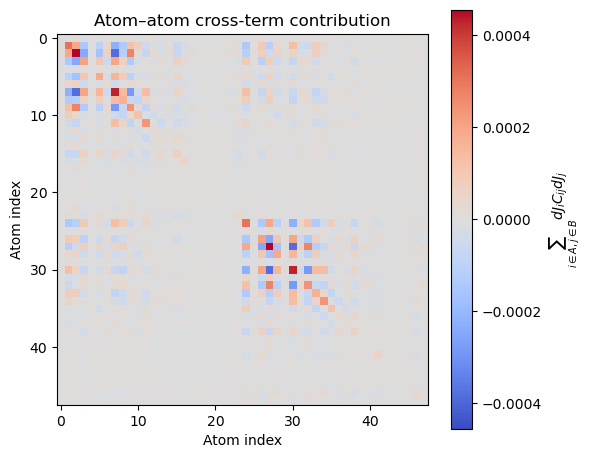

In [19]:
from matplotlib.colors import TwoSlopeNorm

vmax = np.max(np.abs(var_atom_cross))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

plt.figure(figsize=(6, 5))
plt.imshow(var_atom_cross, cmap="coolwarm", norm=norm)
plt.colorbar(label=r"$\sum_{i \in A, j \in B} dJ_i C_{ij} dJ_j$")
plt.xlabel("Atom index")
plt.ylabel("Atom index")
plt.title("Atom–atom cross-term contribution")
plt.tight_layout()
plt.show()